In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   width_shift_range=0.2,  # Shift horizontally
                                   height_shift_range=0.2, # Shift vertically
                                   fill_mode='nearest',                                   
                                   rotation_range = 40)

val_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('Dataset/train',
                                                 target_size = (128, 128),
                                                 batch_size = 1,
                                                 class_mode = 'binary',
                                                 color_mode='grayscale')
val_set = val_datagen.flow_from_directory('Dataset/val',
                                            target_size = (128, 128),
                                            batch_size = 1,
                                            class_mode = 'binary',
                                            color_mode='grayscale')

test_set = val_datagen.flow_from_directory('Dataset/test', # Path to your test folder
                                            target_size = (128, 128),
                                            batch_size = 1,
                                            class_mode = 'binary',
                                            color_mode='grayscale',
                                            shuffle = False) # CRITICAL for the report

Found 80 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Found 10 images belonging to 2 classes.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [4]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape = (128, 128, 1), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(64, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 1, activation = 'sigmoid'))

c:\Users\acer\Desktop\Data-Science-Portfolio\Image Classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-7,verbose=1), 
             EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]

model.fit(training_set, epochs=100, validation_data=val_set, callbacks=callbacks)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5125 - loss: 0.7645 - val_accuracy: 0.5000 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.4625 - loss: 0.6973 - val_accuracy: 0.5000 - val_loss: 0.6930 - learning_rate: 0.0010
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5500 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.7046 - learning_rate: 0.0010
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5250 - loss: 0.7151 - val_accuracy: 0.5000 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5750 - loss: 0.7872 - val_accuracy: 0.5000 - val_loss: 0.7763 - learning_rate: 0.0010
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5625 - loss: 0.6969 - val_accuracy: 0.4500 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5625 - loss: 0.6929 - 

In [7]:
loss, accuracy = model.evaluate(val_set)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9500 - loss: 0.2318
Test loss: 0.2318192422389984
Test accuracy: 0.949999988079071


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


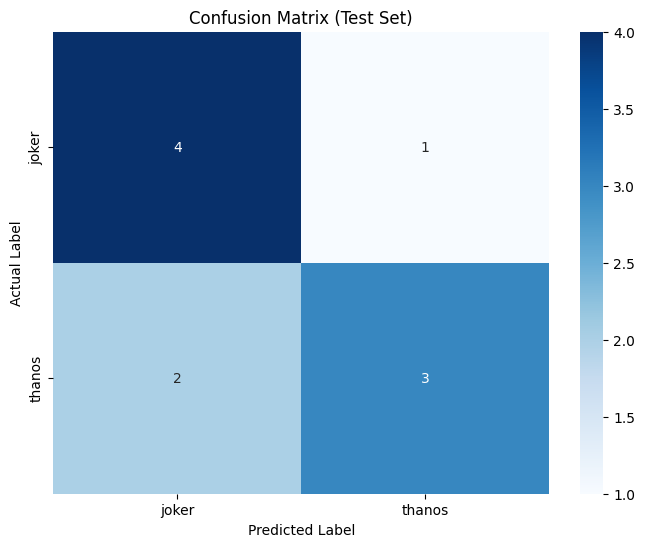

              precision    recall  f1-score   support

       joker       0.67      0.80      0.73         5
      thanos       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Prepare the TEST set (Use test_set for the final evaluation)
test_set.reset()
test_set.shuffle = False 

# 2. Get predictions
predictions = model.predict(test_set)

# 3. Convert probabilities to binary classes (0 or 1)
y_pred = (predictions > 0.5).astype("int32")

# 4. Get true labels and class names from the test_set
y_true = test_set.classes
class_names = list(test_set.class_indices.keys())

# 5. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Detailed Performance Report
print(classification_report(y_true, y_pred, target_names=class_names))

In [10]:
for i in range(len(y_true)):
    if y_pred[i] != y_true[i]:
        print(f"Mistake: Predicted {class_names[y_pred[i][0]]} but it was actually {class_names[y_true[i]]}")
        print(f"Filename: {test_set.filenames[i]}")

Mistake: Predicted thanos but it was actually joker
Filename: joker\joker5.jpeg
Mistake: Predicted joker but it was actually thanos
Filename: thanos\thanos3.jpeg
Mistake: Predicted joker but it was actually thanos
Filename: thanos\thanos5.jpeg


In [12]:
# Save Structure
model_json = model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

# Save Weights
model.save_weights("model.weights.h5")
print("Saved model to disk")


Saved model to disk
